In [1]:
# Remove unwanted warning
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import K_Means_Clustering as km

# Data Management
import pandas as pd
import numpy as np
import polars as pl
import pyarrow as pa
from pandas_datareader.data import DataReader
from ta import add_all_ta_features

# Feature Engineering
from sklearn.preprocessing import StandardScaler

# Cointegration and Statistics
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
from functools import partial

# Machine Learning
from sklearn.cluster import KMeans
from sklearn import metrics
from kneed import KneeLocator

# Reporting
import matplotlib.pyplot as plt

# Operating System
import os
import gc
import multiprocessing as mp

In [2]:
# Global Variables
CSV_FILENAME = "stocks.csv"
PARQET_FILENAME = "stocks.parquet"
WORKING_DIR = "data/"
FEATURES = ["gvkey"]
load_coint_pairs = False

### Data Extraction

In [3]:
if not os.path.exists(os.path.join(
        WORKING_DIR, CSV_FILENAME
    )):
    # read sample data
    file_path = os.path.join(
        WORKING_DIR, "ret_sample.csv"
    )
    data = pl.read_csv(file_path)
    data = data.filter(pl.col("excntry").is_in(["CAN","USA"]))
    # write the North American csv
    data.write_csv(os.path.join(WORKING_DIR, CSV_FILENAME))

if not os.path.exists(os.path.join(
    WORKING_DIR, PARQET_FILENAME
    )):
    # write the parquet file (more memory efficient)
    data = pd.read_csv(os.path.join(WORKING_DIR, CSV_FILENAME), dtype={4: str})
    data.to_parquet(PARQET_FILENAME, index=False, compression="snappy")

# read the parquet file
data = pd.read_parquet(os.path.join(WORKING_DIR, PARQET_FILENAME))




In [4]:
# Display basic information
print("DataFrame Head:")
data.head()
print(data.shape)

DataFrame Head:
(1398807, 159)


In [5]:
data

,id,date,ret_eom,gvkey,iid,excntry,stock_ret,year,month,char_date,...,betadown_252d,prc_highprc_252d,corr_1260d,betabab_1260d,rmax5_rvol_21d,age,qmj,qmj_prof,qmj_growth,qmj_safety
0,comp_001081_01C,20050228,20050228,1081.0,01C,CAN,-0.143457,2005,2,20050131,...,0.779315,0.672204,0.387781,0.845865,0.805580,541,-1.508294,-0.994164,-0.832048,-1.017248
1,comp_001096_01C,20050228,20050228,1096.0,01C,CAN,0.028077,2005,2,20050131,...,0.445162,0.937664,0.245148,0.456872,0.923214,517,-0.706080,-0.247574,-0.155802,-0.485635
2,comp_001117_02,20050228,20050228,1117.0,02,USA,-0.168627,2005,2,20050131,...,1.073565,0.708333,0.124188,0.863334,0.898113,373,1.344458,1.601108,1.612067,-0.566631
3,comp_001186_01C,20050228,20050228,1186.0,01C,CAN,0.149056,2005,2,20050131,...,1.326215,0.774557,0.174888,0.399060,0.777183,385,1.123762,0.154734,1.196690,0.939661
4,comp_001243_01C,20050228,20050228,1243.0,01C,CAN,0.006239,2005,2,20050131,...,1.259809,0.764020,0.474511,0.908097,0.883391,661,-0.719340,-0.170207,-0.825418,0.077587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1398802,comp_330888_01,20250630,20250630,330888.0,01,USA,-0.013834,2025,6,20250530,...,1.016282,0.579611,NaN,NaN,0.997083,497,1.549505,1.538798,1.530902,0.267854
1398803,comp_343592_01,20250630,20250630,343592.0,01,USA,-0.095628,2025,6,20250530,...,0.772162,0.970822,0.204931,1.259553,3.416032,113,NaN,-1.668837,NaN,-0.835244
1398804,comp_347085_01,20250630,20250630,347085.0,01,USA,-0.117477,2025,6,20250530,...,1.074470,1.000000,0.279023,0.957930,1.353505,497,0.774365,1.725188,-1.242550,0.807882
1398805,comp_349705_01,20250630,20250630,349705.0,01,USA,-0.030758,2025,6,20250530,...,1.214794,0.620976,NaN,NaN,1.120641,497,NaN,0.680539,NaN,-1.676248


In [6]:
specific_id = "crsp_14322"  # replace with your target ID
exists = specific_id in data['id'].values
print(f"ID {specific_id} exists: {exists}")

ID crsp_14322 exists: True


In [7]:
# this will give us all the companies we want by removing ones from the same company
print(data.shape)
df_no_duplicate = data.drop_duplicates(subset=["id"], keep='first')
print(df_no_duplicate.shape)
df_no_duplicate = df_no_duplicate.drop_duplicates(subset=["gvkey"], keep="first")
df_ids = df_no_duplicate["id"]
print(df_ids.shape)
del df_no_duplicate
gc.collect()
type(df_ids.values)

(1398807, 159)
(16739, 159)
(13661,)


numpy.ndarray

In [8]:
year = 2015
df_used_comps = data[data["id"].isin(df_ids.values)]
del data
gc.collect()
# Get companies that exist in the target year
companies_in_target_year = df_used_comps[df_used_comps['date'] // 10000 == year]['id'].unique()

# Keep only rows for companies that exist in target year
df_used_comps = df_used_comps[df_used_comps['id'].isin(companies_in_target_year)]
# only keep until the year we want
year *= 10000
df_used_comps = df_used_comps[df_used_comps["date"] < year]

In [9]:
series1 = df_used_comps[df_used_comps["id"] == "comp_001117_02"]
series2 = df_used_comps[df_used_comps["id"] == "crsp_60871"]
series2_values = series2["stock_ret"].cumsum().values / series2["stock_ret"].iloc[0].item()
series1_values = series1["stock_ret"].cumsum().values / series1["stock_ret"].iloc[0].item()
plt.figure(1, figsize=(20,8))
plt.plot(series2_values)
plt.plot(series1_values)
plt.show()

IndexError: single positional indexer is out-of-bounds

In [ ]:
series1

In [23]:
df_ret = df_used_comps.pivot(index="date", columns="id", values="stock_ret")
df_ret = df_ret.sort_index()
df_ret.fillna(value=0, inplace=True)
# df_ret.fillna(value=1, inplace=True)
initial_price = 100
df_ret = (1 + df_ret).cumprod()*100
# df_ret = (1 + df_ret).cumprod() * initial_price

In [24]:
column_name = "crsp_14322"  # replace with your target column name
exists = column_name in df_ret.columns
print(f"Column '{column_name}' exists: {exists}")

Column 'crsp_14322' exists: False


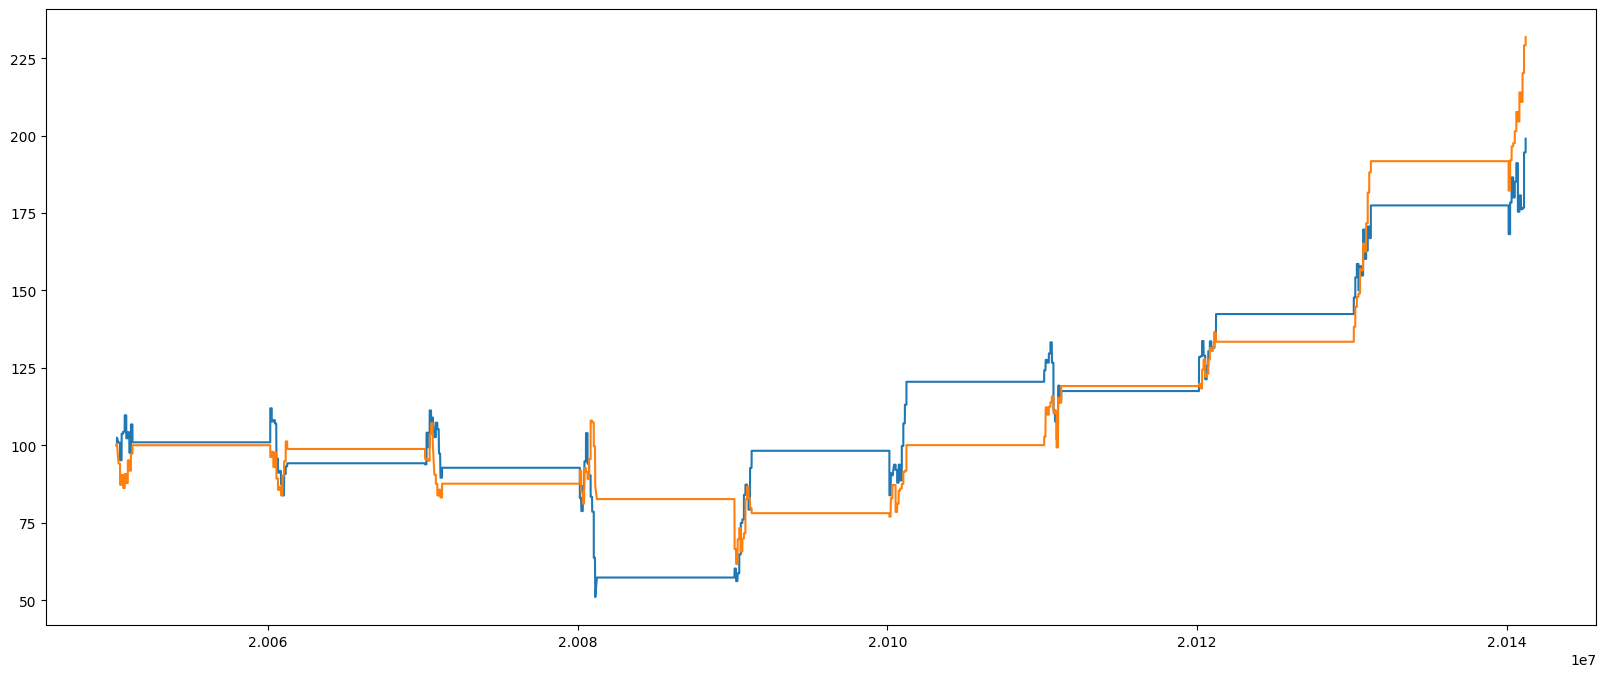

In [25]:
series1 = df_ret["crsp_45751"]
series2 = df_ret["crsp_60871"]
plt.figure(1, figsize=(20,8))
plt.plot(series2)
plt.plot(series1)
plt.show()

In [21]:
# the features that we need for K-Means Clustering
k_means_features = ["id", "excntry", "beta_60m", "betadown_252d", "ivol_capm_252d", "corr_1260d",
                    "dolvol_126d", "bidaskhl_21d", "market_equity", "be_me", "ebitda_mev", "ni_be"]
df_kmeans_raw = df_used_comps[k_means_features]
df_kmeans_raw

,id,excntry,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be
1,comp_001096_01C,CAN,0.423608,0.445162,0.015467,0.245148,1.708334e+05,0.008006,301.116426,1.512289,0.094516,-0.009665
3,comp_001186_01C,CAN,0.220041,1.326215,0.015602,0.174888,4.953975e+06,0.004598,1099.753789,0.454720,0.058404,0.069303
5,comp_001262_01C,CAN,0.409683,0.326245,0.016864,0.258753,1.988377e+04,0.006279,233.972662,1.053347,0.203784,0.051380
8,comp_001828_01C,CAN,0.482820,0.299607,0.011211,0.232040,1.045422e+06,0.005153,1250.994606,0.910321,0.223292,0.108850
9,comp_002055_01C,CAN,0.506174,1.366415,0.012937,0.285375,3.139672e+07,0.002668,11652.020235,0.304153,0.055773,0.047686
...,...,...,...,...,...,...,...,...,...,...,...,...
731527,crsp_93428,USA,1.287472,0.676067,0.025175,0.343495,6.546325e+06,0.007958,776.924770,0.279866,0.005099,-0.042905
731528,crsp_93429,USA,0.550775,0.765164,0.012866,0.435073,3.622505e+07,0.006971,5056.344077,0.054860,0.066961,0.646992
731529,crsp_93433,USA,2.470811,0.901662,0.048974,0.313479,5.889188e+04,0.023577,5.662254,0.008830,NaN,-487.020000
731530,crsp_93434,USA,0.056181,1.152274,0.035907,0.172292,4.811824e+05,0.024368,42.905121,1.203143,0.037132,0.007226


In [22]:
# find the mean of each feature for each company
numeric_profiles = df_kmeans_raw.groupby("id").mean(numeric_only=True)

# the country is also relevant for finding out if 2 stocks are related, so we one-hot encode the country
categorical_profiles = df_kmeans_raw.groupby("id").agg({
    "excntry": "first",
}).reset_index()
categorical_dummies = pd.get_dummies(categorical_profiles, columns=["excntry"], prefix="country")
df_kmeans = numeric_profiles.merge(categorical_dummies, on='id')

In [23]:
# clean up data we don't need to save memory
del df_kmeans_raw
gc.collect()
df_kmeans


,id,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_CAN,country_USA
0,comp_001096_01C,0.998435,0.640172,0.018128,0.470540,2.596834e+05,0.004855,766.087964,1.499063,0.069519,0.071129,1,0
1,comp_001186_01C,0.900235,1.429606,0.024792,0.510581,3.828259e+07,0.008479,6819.428825,0.434357,0.038821,0.029312,1,0
2,comp_001262_01C,0.768548,0.496546,0.016790,0.473588,7.235307e+04,0.009261,401.566398,1.087041,0.193838,0.090924,1,0
3,comp_001828_01C,0.684025,0.711078,0.014560,0.585712,3.669349e+06,0.005304,2836.528988,0.788511,0.213963,0.119374,1,0
4,comp_002055_01C,0.890375,1.230468,0.021255,0.530626,1.094271e+08,0.007284,31062.649353,0.562505,0.067181,-0.023250,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5099,crsp_93428,1.280755,0.551290,0.039515,0.341977,1.707230e+07,0.011081,788.676427,0.171083,0.024988,0.079224,0,1
5100,crsp_93429,0.523453,0.744000,0.013627,0.448848,2.098400e+07,0.006000,2809.869117,0.200878,0.180858,0.502726,0,1
5101,crsp_93433,2.563137,1.435955,0.056548,0.333073,4.807046e+06,0.021997,173.406000,1.079014,-0.041936,-79.664588,0,1
5102,crsp_93434,-0.015549,0.705201,0.032312,0.162187,3.224584e+05,0.014800,51.162037,0.529407,-0.003012,-0.001588,0,1


In [24]:
# Remove any companies with NaN values
df_kmeans.dropna(inplace=True)
print("has NaN values:", df_kmeans.isnull().values.any())
df_kmeans

has NaN values: False


,id,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_CAN,country_USA
0,comp_001096_01C,0.998435,0.640172,0.018128,0.470540,2.596834e+05,0.004855,766.087964,1.499063,0.069519,0.071129,1,0
1,comp_001186_01C,0.900235,1.429606,0.024792,0.510581,3.828259e+07,0.008479,6819.428825,0.434357,0.038821,0.029312,1,0
2,comp_001262_01C,0.768548,0.496546,0.016790,0.473588,7.235307e+04,0.009261,401.566398,1.087041,0.193838,0.090924,1,0
3,comp_001828_01C,0.684025,0.711078,0.014560,0.585712,3.669349e+06,0.005304,2836.528988,0.788511,0.213963,0.119374,1,0
4,comp_002055_01C,0.890375,1.230468,0.021255,0.530626,1.094271e+08,0.007284,31062.649353,0.562505,0.067181,-0.023250,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5099,crsp_93428,1.280755,0.551290,0.039515,0.341977,1.707230e+07,0.011081,788.676427,0.171083,0.024988,0.079224,0,1
5100,crsp_93429,0.523453,0.744000,0.013627,0.448848,2.098400e+07,0.006000,2809.869117,0.200878,0.180858,0.502726,0,1
5101,crsp_93433,2.563137,1.435955,0.056548,0.333073,4.807046e+06,0.021997,173.406000,1.079014,-0.041936,-79.664588,0,1
5102,crsp_93434,-0.015549,0.705201,0.032312,0.162187,3.224584e+05,0.014800,51.162037,0.529407,-0.003012,-0.001588,0,1


In [25]:
# Check for any infinite values
dfobj = df_kmeans.isin([np.inf, -np.inf])
count = np.isinf(dfobj).values.sum()
print("Infinite Values:", count)

# Garbage collection to save memory
del dfobj
gc.collect()

Infinite Values: 0


0

In [26]:
df_kmeans.info()
df_kmeans

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4013 entries, 0 to 5103
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              4013 non-null   object 
 1   beta_60m        4013 non-null   float64
 2   betadown_252d   4013 non-null   float64
 3   ivol_capm_252d  4013 non-null   float64
 4   corr_1260d      4013 non-null   float64
 5   dolvol_126d     4013 non-null   float64
 6   bidaskhl_21d    4013 non-null   float64
 7   market_equity   4013 non-null   float64
 8   be_me           4013 non-null   float64
 9   ebitda_mev      4013 non-null   float64
 10  ni_be           4013 non-null   float64
 11  country_CAN     4013 non-null   uint8  
 12  country_USA     4013 non-null   uint8  
dtypes: float64(10), object(1), uint8(2)
memory usage: 384.1+ KB


,id,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_CAN,country_USA
0,comp_001096_01C,0.998435,0.640172,0.018128,0.470540,2.596834e+05,0.004855,766.087964,1.499063,0.069519,0.071129,1,0
1,comp_001186_01C,0.900235,1.429606,0.024792,0.510581,3.828259e+07,0.008479,6819.428825,0.434357,0.038821,0.029312,1,0
2,comp_001262_01C,0.768548,0.496546,0.016790,0.473588,7.235307e+04,0.009261,401.566398,1.087041,0.193838,0.090924,1,0
3,comp_001828_01C,0.684025,0.711078,0.014560,0.585712,3.669349e+06,0.005304,2836.528988,0.788511,0.213963,0.119374,1,0
4,comp_002055_01C,0.890375,1.230468,0.021255,0.530626,1.094271e+08,0.007284,31062.649353,0.562505,0.067181,-0.023250,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5099,crsp_93428,1.280755,0.551290,0.039515,0.341977,1.707230e+07,0.011081,788.676427,0.171083,0.024988,0.079224,0,1
5100,crsp_93429,0.523453,0.744000,0.013627,0.448848,2.098400e+07,0.006000,2809.869117,0.200878,0.180858,0.502726,0,1
5101,crsp_93433,2.563137,1.435955,0.056548,0.333073,4.807046e+06,0.021997,173.406000,1.079014,-0.041936,-79.664588,0,1
5102,crsp_93434,-0.015549,0.705201,0.032312,0.162187,3.224584e+05,0.014800,51.162037,0.529407,-0.003012,-0.001588,0,1


### Feature Scaling

In [27]:
non_scalable = df_kmeans[["id", "country_USA", "country_CAN"]].copy()
scalable = df_kmeans.drop(columns=["id", "country_USA", "country_CAN"])

scaler = StandardScaler()
scaler = scaler.fit_transform(scalable)
df_kmeans_scaled = pd.DataFrame(scaler, columns=scalable.columns, index=scalable.index)
df_kmeans_scaled = pd.concat([df_kmeans_scaled, non_scalable], axis=1)
df_kmeans_scaled = df_kmeans_scaled.set_index('id')

del df_kmeans
gc.collect()

df_kmeans_scaled

,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_USA,country_CAN
id,,,,,,,,,,,,
comp_001096_01C,-0.363354,-0.912538,-0.723228,0.306578,-0.330985,-0.607772,-0.197703,0.998148,0.019214,0.084291,0,1
comp_001186_01C,-0.524191,0.933893,-0.303380,0.540003,0.109586,-0.371651,0.175910,-0.536248,0.006453,0.073993,0,1
comp_001262_01C,-0.739875,-1.248469,-0.807476,0.324347,-0.333156,-0.320738,-0.220201,0.404365,0.070897,0.089166,0,1
comp_001828_01C,-0.878310,-0.746693,-0.948000,0.977987,-0.291477,-0.578500,-0.069915,-0.025861,0.079263,0.096173,0,1
comp_002055_01C,-0.540341,0.468125,-0.526177,0.656856,0.933936,-0.449508,1.672204,-0.351569,0.018243,0.061048,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
crsp_93428,0.099044,-1.120427,0.624157,-0.442896,-0.136178,-0.202201,-0.196309,-0.915665,0.000702,0.086285,1,0
crsp_93429,-1.141302,-0.669691,-1.006736,0.180124,-0.090853,-0.533158,-0.071561,-0.872725,0.065501,0.190584,1,0
crsp_93433,2.199392,0.948744,1.697208,-0.494804,-0.278295,0.508976,-0.234283,0.392796,-0.027120,-19.552867,1,0


### K-Means Clustering

In [28]:
# Find the optpimum number of clusters
X = df_kmeans_scaled.copy()
K = range(1, 20)
distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

kl = KneeLocator(K,distortions, curve="convex", direction="decreasing")
c = kl.elbow
print("Optimum Clusters:", c)

Optimum Clusters: 6


In [36]:
# Fit K-Means Model
k_means = KMeans(n_clusters=c)
k_means.fit(X)
prediction = k_means.predict(df_kmeans_scaled)

In [37]:
# Return the series
clustered_series = pd.Series(index=X.index, data=k_means.labels_.flatten())
clustered_series_all = pd.Series(index=X.index, data=k_means.labels_.flatten())
clustered_series = clustered_series[clustered_series != -1]
clustered_series.tail()

id
crsp_93428    1
crsp_93429    2
crsp_93433    0
crsp_93434    1
crsp_93436    2
dtype: int32

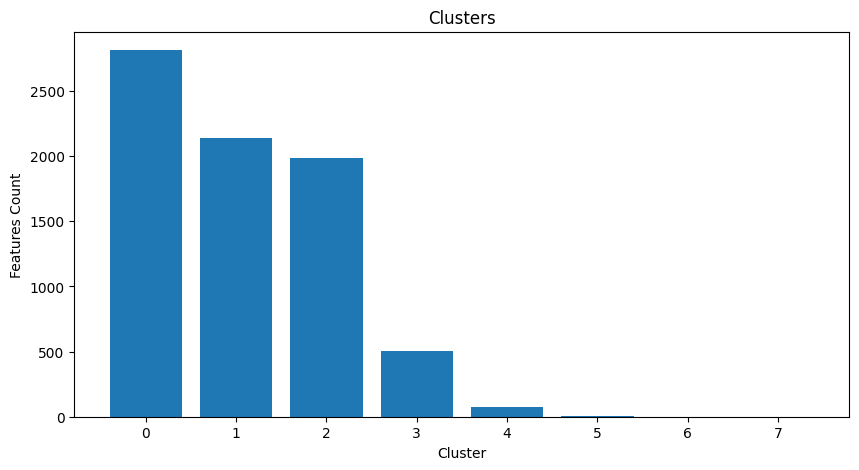

In [38]:
plt.figure(figsize=(10,5))
plt.bar(range(len(clustered_series.value_counts())), clustered_series.value_counts())
plt.title("Clusters")
plt.xlabel("Cluster")
plt.ylabel("Features Count")
plt.show()

In [39]:
clustered_series.value_counts()

2    2814
1    2136
0    1986
5     505
3      71
4       2
6       1
7       1
dtype: int64

In [40]:
# Remvoe Items if Preferred
print(clustered_series.value_counts())
clusters_clean = clustered_series
print("Feature Number Previous: ", len(clustered_series))
print("Feature Number Current: ", len(clusters_clean))
clusters_clean

2    2814
1    2136
0    1986
5     505
3      71
4       2
6       1
7       1
dtype: int64
Feature Number Previous:  7516
Feature Number Current:  7516


id
comp_001081_01C    2
comp_001096_01C    2
comp_001117_02     1
comp_001186_01C    2
comp_001243_01C    2
                  ..
crsp_93428         1
crsp_93429         2
crsp_93433         0
crsp_93434         1
crsp_93436         2
Length: 7516, dtype: int32

### Calculate Cointegration

In [41]:
foo = 1

In [42]:
def calculate_cointegration(series_1, series_2, sig_level=0.05):
    # Engle–Granger test
    coint_res = coint(series_1, series_2)
    coint_t, p_value, crit_values = coint_res

    # regression to estimate hedge ratio
    X = sm.add_constant(series_2)
    model = sm.OLS(series_1, X).fit()
    hedge_ratio = model.params[1]

    # cointegration flag (use both critical value + p-value check)
    coint_flag = int((coint_t < crit_values[1]) and (p_value < sig_level))
    

    # define a "strength score" (lower p-value = stronger)
    # you can also do something like (crit_values[1] - coint_t) for distance from threshold
    score = -p_value  

    return {
        "flag": coint_flag,
        "hedge_ratio": hedge_ratio,
        "p_value": p_value,
        "score": score
    }

In [43]:
def test_pair_cointegration(pair_data, df_ret):
    """Helper function for parallel processing"""
    base_asset, compare_asset, label = pair_data
    series_1 = df_ret[base_asset].values.astype(float)
    series_2 = df_ret[compare_asset].values.astype(float)
    
    coint_flag, *_ = calculate_cointegration(series_1, series_2)
    if coint_flag == 1:
        print("we are adding")
        return {
            "base asset": base_asset,
            "compare asset": compare_asset,
            "label": label
        }
    return None

In [44]:
# Strategy 5: Combined Approach (Recommended)
def optimize_cointegration_testing_combined(clusters_clean, df_ret, 
                                           corr_threshold=0.6, 
                                           max_pairs_per_cluster=100,
                                           n_processes=None):
    """
    Combine correlation filtering with parallel processing
    """
    all_pairs_to_test = []
    
    for label in clusters_clean.unique():
        cluster_assets = clusters_clean[clusters_clean == label].index.tolist()
        if len(cluster_assets) <= 1:
            continue
            
        # Pre-filter by correlation
        cluster_data = df_ret[cluster_assets]
        corr_matrix = cluster_data.corr()
        
        high_corr_pairs = []
        for i, asset1 in enumerate(cluster_assets):
            for j, asset2 in enumerate(cluster_assets[i+1:], i+1):
                corr_val = abs(corr_matrix.loc[asset1, asset2])
                if corr_val > corr_threshold:
                    high_corr_pairs.append((asset1, asset2, corr_val, label))
        
        # Sort by correlation and limit
        high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
        high_corr_pairs = high_corr_pairs[:max_pairs_per_cluster]
        
        all_pairs_to_test.extend([(pair[0], pair[1], pair[3]) for pair in high_corr_pairs])
    
    print(f"After correlation filtering: {len(all_pairs_to_test)} pairs to test")
    return all_pairs_to_test
    
    # # Parallel processing
    # if n_processes is None:
    #     n_processes = mp.cpu_count() - 1
    
    # with mp.Pool(processes=n_processes) as pool:
    #     test_func = partial(test_pair_cointegration, df_ret=df_ret)
    #     results = pool.map(test_func, all_pairs_to_test)
    
    # cointegrated_pairs = [result for result in results if result is not None]
    
    # return pd.DataFrame(cointegrated_pairs).sort_values(by="label")

In [45]:
if not load_coint_pairs:
    # Choose your strategy:
    
    # Fast but less comprehensive
    # df_coint = optimize_cointegration_testing_v1(clusters_clean, df_ret, sample_size=5000)
    
    # Correlation-based filtering
    # df_coint = optimize_cointegration_testing_v2(clusters_clean, df_ret, corr_threshold=0.7, max_pairs_per_cluster=100)
    
    # Representative selection
    # df_coint = optimize_cointegration_testing_v3(clusters_clean, df_ret, n_representatives=50)
    
    # Recommended: Combined approach
    df_coint = optimize_cointegration_testing_combined(
        clusters_clean, df_ret, 
        corr_threshold=0.6, 
        max_pairs_per_cluster=100,
        n_processes=4  # Adjust based on your CPU
    )

After correlation filtering: 500 pairs to test


In [46]:
# Loop through and calculate cointegrate pairs
cointegrated_pairs = []
for tup in df_coint:
    series_1 = df_ret[tup[0]].values.astype(float)
    series_2 = df_ret[tup[1]].values.astype(float)
    temp = calculate_cointegration(series_1, series_2)
    temp["base asset"] = tup[0]
    temp["compare asset"] = tup[1]
    cointegrated_pairs.append(temp)
df_coint_new = pd.DataFrame(cointegrated_pairs)
    # df_coint.to_csv(file_name_coint)
df_coint_new

/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/pyt

,flag,hedge_ratio,p_value,score,base asset,compare asset
0,1,-0.027454,0.000000,-0.000000,crsp_14322,crsp_76101
1,1,0.612249,0.000000,-0.000000,crsp_14322,crsp_86401
2,1,-1.883009,0.000000,-0.000000,crsp_10906,crsp_14322
3,1,-1.152870,0.000000,-0.000000,crsp_10906,crsp_86401
4,1,-22.300740,0.000000,-0.000000,crsp_76101,crsp_86401
...,...,...,...,...,...,...
495,0,1.772174,0.102297,-0.102297,crsp_66181,crsp_87447
496,0,0.653005,0.136712,-0.136712,crsp_13856,crsp_22752
497,0,0.374680,0.069849,-0.069849,crsp_14541,crsp_84788
498,0,0.631003,0.158753,-0.158753,crsp_13856,crsp_65875


In [47]:
df_coint_new = df_coint_new[df_coint_new["flag"] == 1]
available_stocks = set(df_temp['id'].unique())
df_temp = km.get_stock_returns_upto_year(
# Keep pairs where both stocks exist in df_temp
mask = (df_coint_new.iloc[:, 0].isin(available_stocks)) & \
    (df_coint_new.iloc[:, 1].isin(available_stocks))

df_coint_filtered = df_coint_new[mask]
df_coint_new.sort_values(by="score")

,flag,hedge_ratio,p_value,score,base asset,compare asset
379,1,3.097297,0.047800,-0.047800,comp_106808_01C,comp_138841_01C
43,1,0.914651,0.045858,-0.045858,crsp_76796,crsp_89928
410,1,0.390013,0.045659,-0.045659,crsp_12490,crsp_14593
243,1,0.908626,0.044241,-0.044241,crsp_66130,crsp_89806
457,1,1.479714,0.042064,-0.042064,crsp_17830,crsp_18163
...,...,...,...,...,...,...
159,1,2.545599,0.000000,-0.000000,crsp_11646,crsp_86156
160,1,-1.421089,0.000000,-0.000000,crsp_40097,crsp_81865
161,1,-0.474447,0.000000,-0.000000,crsp_40097,crsp_79087
150,1,40.018034,0.000000,-0.000000,crsp_11646,crsp_76830


In [43]:
df_coint_csv = df_coint_new.iloc[:, 4:]
df_coint_csv = df_coint_csv.iloc[:50]
# df_coint_csv.to_csv("data/cointegrated-pairs.csv", index=False)
df_coint_csv

,base asset,compare asset
0,crsp_14322,crsp_76101
1,crsp_14322,crsp_86401
2,crsp_10906,crsp_14322
3,crsp_10906,crsp_86401
4,crsp_76101,crsp_86401
5,crsp_10906,crsp_76101
6,comp_162940_02C,crsp_59248
7,crsp_77106,crsp_86813
8,crsp_14322,crsp_77106
9,crsp_76101,crsp_77106


In [ ]:
# Loop through and calculate cointegrate pairs
tested_pairs = []
cointegrated_pairs = []
if not load_coint_pairs:
    for base_asset in clusters_clean.index:
        base_label = clusters_clean[base_asset]
        for compare_asset in clusters_clean.index:
            compare_label = clusters_clean[compare_asset]
            test_pair = str(base_asset) + str(compare_asset)
            test_pair = ''.join(sorted(test_pair))
            is_tested = test_pair in tested_pairs
            tested_pairs.append(test_pair)
            if compare_asset != base_asset and base_label == compare_label and not is_tested:

                series_1 = df_ret[base_asset].values.astype(float)
                series_2 = df_ret[compare_asset].values.astype(float)
                print(series_1)
                print(series_2)
                coint_flag, _ = calculate_cointegration(series_1, series_2)
                if coint_flag == 1:
                    print("adding")
                    cointegrated_pairs.append({
                        "base asset": base_asset,
                        "compare asset": compare_asset,
                        "label": base_label})
    df_coint = pd.DataFrame(cointegrated_pairs).sort_values(by="label")
    # df_coint.to_csv(file_name_coint)                              

In [ ]:
df_coint

In [ ]:
series1 = df_ret["crsp_60871"].values
series2 = df_ret["crsp_78987"].values
xpoints = df_ret.index.values
plt.figure(1, figsize=(20,8))
plt.plot(xpoints, series1)
plt.plot(xpoints, series2)
plt.show()

In [ ]:
df_ret